# 3D Geometry — Mesh Cross-Sections & Ray Casting

Demonstrates the geometry module's mesh slicing and ray casting on
programmatic tetrahedral meshes. These tools are designed for STEP file
imports (build123d + tetgen), but here we use hand-built meshes so that
the notebook runs without optional dependencies.

1. **Mesh cross-section** — slice a mesh with a plane, color by material
2. **Ray visualization** — cast rays through the mesh, show entry/exit points
3. **Cross-section colored by a quantity** — e.g., energy loss per tet

## 1. Setup

In [1]:
%matplotlib inline

import numpy as np

from hyrr.geometry import (
    MaterialInfo,
    TetrahedralMesh,
    axial_slice,
    cast_ray,
    cut_mesh_with_plane,
    longitudinal_slice,
)
from hyrr.plotting import plot_mesh_cross_section, plot_ray_visualization

## 2. Build a test mesh

Two tetrahedra stacked along z with different materials (copper and
molybdenum). This mimics a simple two-layer target.

In [2]:
nodes = np.array([
    [0.0, 0.0, 0.0],  # 0
    [1.0, 0.0, 0.0],  # 1
    [0.0, 1.0, 0.0],  # 2
    [0.0, 0.0, 1.0],  # 3
    [0.0, 0.0, 2.0],  # 4
], dtype=np.float64)

elements = np.array([
    [0, 1, 2, 3],
    [1, 2, 3, 4],
], dtype=np.int64)

material_ids = np.array([0, 1], dtype=np.int32)

materials = {
    0: MaterialInfo(
        name="copper",
        composition=[(29, 1.0)],
        density_g_cm3=8.96,
        atomic_masses={29: 63.546},
    ),
    1: MaterialInfo(
        name="molybdenum",
        composition=[(42, 1.0)],
        density_g_cm3=10.28,
        atomic_masses={42: 95.95},
    ),
}

mesh = TetrahedralMesh(nodes, elements, material_ids, materials)
print(f"Mesh: {len(nodes)} nodes, {len(elements)} tets, {len(materials)} materials")

Mesh: 5 nodes, 2 tets, 2 materials


## 3. Axial Cross-Section (z = 0.5)

Cut perpendicular to the beam direction at depth z = 0.5.
Should intersect the first tet.

In [3]:
beam_dir = np.array([0.0, 0.0, 1.0])
beam_pos = np.array([0.0, 0.0, 0.0])

point, normal, polygons = axial_slice(mesh, beam_dir, beam_pos, depth_cm=0.5)
print(f"Axial slice at z={point[2]:.1f}: {len(polygons)} polygon(s)")

if polygons:
    plot_mesh_cross_section(
        polygons,
        show_materials=True,
        materials=materials,
        title="Axial Slice at z = 0.5",
    )

Axial slice at z=0.5: 2 polygon(s)


## 4. Longitudinal Cross-Section

Cut along the beam direction through the beam center.
Shows the lateral extent at each depth.

In [4]:
point, normal, polygons = longitudinal_slice(mesh, beam_dir, beam_pos)
print(f"Longitudinal slice: {len(polygons)} polygon(s)")

if polygons:
    plot_mesh_cross_section(
        polygons,
        show_materials=True,
        materials=materials,
        title="Longitudinal Slice",
    )

Longitudinal slice: 2 polygon(s)


## 5. Ray Casting

Cast several parallel rays through the mesh along z and visualise
their paths.

  Ray at (0.05, 0.05): 2 segment(s), total path = 1.8000 cm
  Ray at (0.10, 0.10): 2 segment(s), total path = 1.6000 cm
  Ray at (0.20, 0.10): 2 segment(s), total path = 1.4000 cm
  Ray at (0.10, 0.20): 2 segment(s), total path = 1.4000 cm


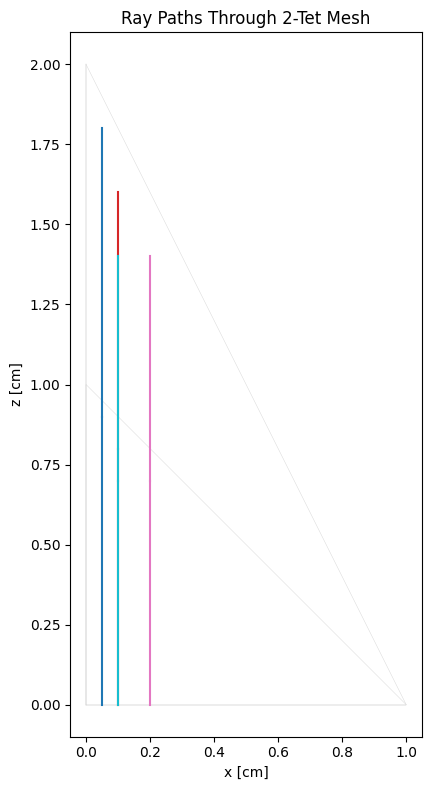

In [5]:
direction = np.array([0.0, 0.0, 1.0])
ray_origins = [
    np.array([0.05, 0.05, -0.5]),
    np.array([0.1, 0.1, -0.5]),
    np.array([0.2, 0.1, -0.5]),
    np.array([0.1, 0.2, -0.5]),
]

all_segments = []
for origin in ray_origins:
    segs = cast_ray(mesh, origin, direction)
    all_segments.append(segs)
    n_hit = len(segs)
    total_path = sum(s.path_length_cm for s in segs)
    print(f"  Ray at ({origin[0]:.2f}, {origin[1]:.2f}): "
          f"{n_hit} segment(s), total path = {total_path:.4f} cm")

plot_ray_visualization(mesh, all_segments, title="Ray Paths Through 2-Tet Mesh")

## 6. Cross-Section Colored by Quantity

Color each tet polygon by a simulated quantity (e.g., energy deposited).
In a real workflow this would come from `compute_3d` results.

In [7]:
point = np.array([0.0, 0.0, 0.5])
normal = np.array([0.0, 0.0, 1.0])
polygons = cut_mesh_with_plane(mesh, point, normal)

# Simulated energy deposition per tet
values = {0: 2.5, 1: 1.8}

if polygons:
    plot_mesh_cross_section(
        polygons,
        values=values,
        quantity_label="Energy deposition [MeV/cm]",
        title="Cross-Section Colored by Energy Deposition",
    )